## Metodología de Identificación de Sistemas para Detección de Anomalías

En un dataset multivariado, un **Sistema** se define como un subconjunto de variables que presentan una fuerte interdependencia física, lógica o estadística. Para que el algoritmo de **Reconstrucción Cruzada** sea efectivo, es imperativo que las variables seleccionadas puedan explicarse entre sí.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

### Dataset con Estructura Latente

In [2]:
# Generamos un dataset con estructuras latentes
np.random.seed(42)
n = 200

# Sistema 1: Variables Mecánicas (A, C, D)
A = np.random.normal(50, 5, n)
C = A * 0.8 + np.random.normal(0, 1, n)
D = A * -0.5 + np.random.normal(0, 1, n)

# Sistema 2: Variables Térmicas (B, E)
B = np.random.normal(100, 10, n)
E = B * 1.5 + np.random.normal(0, 5, n)

# Variable F: Ruido Blanco (No pertenece a ningún sistema)
F = np.random.uniform(0, 100, n)

df = pd.DataFrame({'Temp_Motor': B, 'Presion_A': A, 'Voltaje_E': E, 
                   'Flujo_C': C, 'Vibra_D': D, 'Sensor_Ruido': F})

print("Dataset preparado con 6 variables y 2 sistemas potenciales.")
df.head()

Dataset preparado con 6 variables y 2 sistemas potenciales.


,Temp_Motor,Presion_A,Voltaje_E,Flujo_C,Vibra_D,Sensor_Ruido
0,107.569886,52.483571,166.046248,42.344644,-27.836213,16.748258
1,90.778347,49.308678,133.587296,40.007727,-25.253714,10.456784
2,108.696059,53.238443,163.524693,43.673805,-26.613978,63.643025
3,113.556379,57.615149,168.023191,47.145921,-28.760594,70.647573
4,104.134349,48.829233,154.029042,37.685717,-24.864682,3.158614


## 1. Construcción del Espacio de Distancia
Utilizamos la **Correlación de Spearman** ($\rho$) para medir la asociación. A diferencia de Pearson, Spearman captura relaciones mono-tónicas no lineales. Transformamos la similitud en una métrica de distancia euclidiana proyectada:

$$d(i, j) = \sqrt{2(1 - |\rho_{ij}|)}$$

Propiedades de esta métrica:
* Si $|\rho| = 1$, entonces $d = 0$ (Identidad o correlación perfecta).
* Si $|\rho| = 0$, entonces $d = \sqrt{2} \approx 1.41$ (Independencia).

In [3]:
# Cálculo de la Matriz de Correlación y Distancia
corr_matrix = df.corr(method='spearman').abs()
dist_matrix = np.sqrt(2 * (1 - corr_matrix))
dist_matrix

,Temp_Motor,Presion_A,Voltaje_E,Flujo_C,Vibra_D,Sensor_Ruido
Temp_Motor,0.000000,1.372502,0.289779,1.396173,1.405682,1.333654
Presion_A,1.372502,0.000000,1.375965,0.261812,0.407876,1.407820
Voltaje_E,0.289779,1.375965,0.000000,1.407571,1.409048,1.349489
Flujo_C,1.396173,0.261812,1.407571,0.000000,0.454513,1.407623
Vibra_D,1.405682,0.407876,1.409048,0.454513,0.000000,1.408351
Sensor_Ruido,1.333654,1.407820,1.349489,1.407623,1.408351,0.000000


## 2. Clustering Jerárquico Aglomerativo
Aplicamos el método de **Vínculo Completo (Complete Linkage)**, el cual busca minimizar el diámetro máximo de los clusters, asegurando que todos los elementos dentro de un "Sistema" mantengan una correlación mínima aceptable entre ellos.

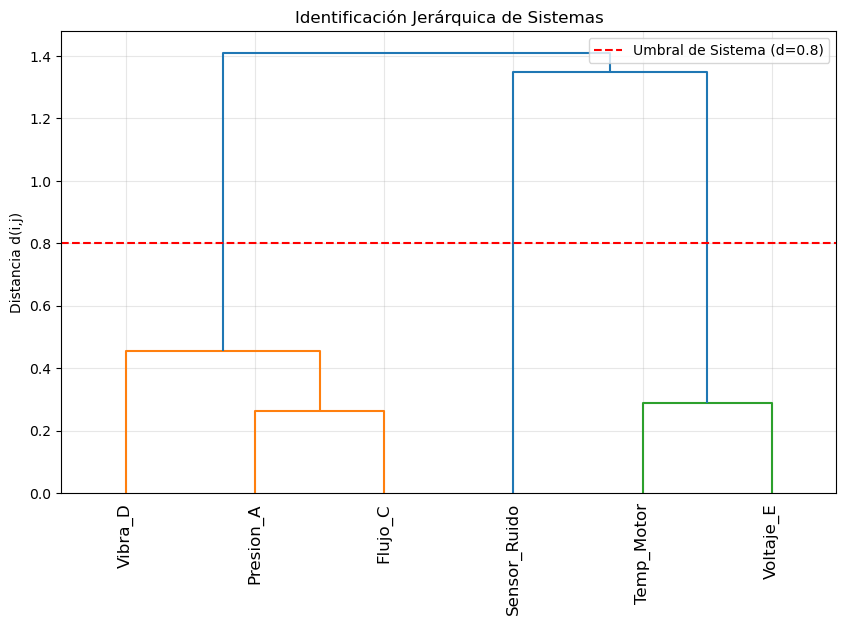

In [4]:
# Clustering Jerárquico
# Convertimos la matriz simétrica en un vector condensado para scipy
Z = linkage(squareform(dist_matrix), method='complete')

# Visualización: Dendrograma
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=df.columns, leaf_rotation=90, color_threshold=0.8)
plt.axhline(y=0.8, color='r', linestyle='--', label='Umbral de Sistema (d=0.8)')
plt.title("Identificación Jerárquica de Sistemas")
plt.ylabel("Distancia d(i,j)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3. Validación de la "Reconstruibilidad" (Métrica $R^2_{adj}$)
Un grupo de variables solo es un sistema útil si podemos predecir una variable $x_i$ usando las demás variables del grupo $X_{j \neq i}$. Evaluamos cada grupo mediante el **Coeficiente de Determinación Ajustado Promedio**:

$$\bar{R}^2_{sys} = \frac{1}{k} \sum_{i=1}^{k} \left( 1 - (1 - R^2_i) \frac{n-1}{n-p-1} \right)$$

Donde $n$ es el número de muestras y $p$ el número de predictores.

In [5]:
def validar_sistemas(df, linkage_matrix, threshold=0.8):
    labels = fcluster(linkage_matrix, threshold, criterion='distance')
    clusters = {}
    for idx, label in enumerate(labels):
        clusters.setdefault(label, []).append(df.columns[idx])
    
    resultados = []
    
    for c_id, variables in clusters.items():
        if len(variables) < 2: continue # Ignorar variables aisladas
        
        r2_list = []
        for v_target in variables:
            X = df[variables].drop(columns=[v_target])
            y = df[v_target]
            
            # Ajuste de regresión rápida para validar interdependencia
            reg = LinearRegression().fit(X, y)
            r2 = r2_score(y, reg.predict(X))
            
            # R2 Ajustado
            n, p = X.shape
            r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
            r2_list.append(r2_adj)
        
        r2_promedio = np.mean(r2_list)
        resultados.append({
            'Sistema_ID': c_id,
            'Variables': variables,
            'R2_Adj_Promedio': round(r2_promedio, 4),
            'Calidad': 'Alta' if r2_promedio > 0.8 else 'Media' if r2_promedio > 0.5 else 'Baja'
        })
    
    return pd.DataFrame(resultados)

reporte = validar_sistemas(df, Z, threshold=0.8)
print("### Reporte de Sistemas Detectados ###")
display(reporte)

### Reporte de Sistemas Detectados ###


,Sistema_ID,Variables,R2_Adj_Promedio,Calidad
0,2,"[Temp_Motor, Voltaje_E]",0.9209,Alta
1,1,"[Presion_A, Flujo_C, Vibra_D]",0.9173,Alta


### Análisis de Resultados

* **Sistemas de Alta Calidad ($R^2 > 0.8$):** Son candidatos ideales para el modelo de reconstrucción. La baja varianza en el error de reconstrucción permitirá establecer umbrales de alarma muy precisos.
* **Variables Aisladas:** Aquellas que no formaron grupos (como `Sensor_Ruido`) no pueden ser monitoreadas bajo esta arquitectura y requieren un enfoque univariado.

**Siguiente Paso:** Una vez definidos los sistemas, el siguiente paso es implementar la **Arquitectura de Reconstrucción $N \times N$** para el sistema seleccionado, calculando los residuos normalizados y el **Total Risk Score**.